## 1 - Importing Libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import seaborn as sns
import argparse
from tqdm import tqdm
from loguru import logger
import json # For saving model parameters

from sklearn.model_selection import KFold
from sklearn.feature_selection import RFECV
from sklearn.model_selection import cross_val_score
from skopt import BayesSearchCV
from skopt.callbacks import DeadlineStopper, DeltaYStopper
from skopt.space import Real, Integer

## 2- Fix Random Seed

In [6]:
# add code here
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 3 - Data ingestion and preprocessing stage
Loading the training dataset and standardizing the naming of features for readability, focusing on numeric descriptors.

In [13]:
def load_train():
    file_path_train = 'Data/cycle_dataset.csv'
    # Load the CSV into a pandas DataFrame
    df_train = pd.read_csv(file_path_train)
    # df_train = df_train.rename(columns = {"ASA [m^2/cm^3]" : "ASA_vol",
    #                                     "NASA [m^2/cm^3]" : "NASA_vol",
    #                                     "POAV [cm^3/g]" : "POAV_grav",
    #                                     "PONAV [cm^3/g]" : "PONAV_grav",
    #                                     "density [g/cm^3]" : "density"}
    #                                     )

    # df_train = df_train.drop_duplicates()
    
    # Only include numeric columns as descriptors (exclude 'sample_name' and 'trial' which are categorical)
    numeric_columns = df_train.select_dtypes(include=[np.number]).columns.tolist()
    # Remove the target variable 'viscosity_cp' from features
    descriptor_names = [col for col in numeric_columns if col != 'viscosity_cp']

    return df_train, descriptor_names

def load_test():
    file_path_test = 'Data/cycle_dataset_1.0.csv'
    # Load the CSV into a pandas DataFrame
    df_test = pd.read_csv(file_path_test)
    # df_test = df_test.rename(columns = {"ASA [m^2/cm^3]" : "ASA_vol",
    #                                     "NASA [m^2/cm^3]" : "NASA_vol",
    #                                     "POAV [cm^3/g]" : "POAV_grav",
    #                                     "PONAV [cm^3/g]" : "PONAV_grav",
    #                                     "density [g/cm^3]" : "density"}
    #                                     )
    
    return df_test

def baseline_model(test_size = 0.2):
    df_train, descriptor_names = load_train()
    label = "viscosity_cp"
    X, y = df_train[descriptor_names], df_train[label]

    X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED)

    model = xgb.XGBRegressor()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    logger.info(f'R2: {r2_score(y_val, y_pred)}, MAE: {mean_absolute_error(y_val, y_pred)} cP')

In [8]:
df_test = load_test()
df_test.head()

,sample_name,trial,cycle_number,line1_slope,line1_intercept,line2_quad_coeff,line2_line_coeff,line2_const_coeff,line3_quad_coeff,line3_line_coeff,line3_const_coeff,line4_slope,line4_intercept,max_peak,min_peak,time_line1,time_line2,time_line3,time_line4,viscosity_cp
0,water,b1,1,0.731729,-6.532336,-0.021634,0.616791,-3.925073,0.014315,-0.571064,5.897637,-1.554066,33.906207,0.478354,-1.266337,1.0,6.502,6.002,1.002,1
1,water,b1,2,1.250543,-29.251541,-0.022203,1.273077,-17.802528,0.010645,-0.740485,13.099634,-1.719171,62.435686,0.483577,-1.410606,1.0,6.001,6.500,1.000,1
2,water,b1,3,1.429857,-54.147489,-0.017092,1.506034,-32.705375,0.005082,-0.517551,13.393180,-1.776986,91.172279,0.450223,-1.464363,1.0,5.500,7.500,1.000,1
3,water,b1,4,1.468514,-77.658883,-0.022521,2.614603,-75.432130,0.009337,-1.206154,39.162354,-1.471414,96.856177,0.477880,-1.476057,1.0,6.000,6.501,1.000,1
4,water,b1,5,1.190057,-80.194055,-0.022256,3.237039,-117.249279,0.010655,-1.676432,66.170914,-1.525586,122.587985,0.485491,-1.212923,1.0,6.003,6.509,1.000,1


## 4 - Feature Selection (wrapper method)
An XGBoost Regressor is trained once to estimate feature importance and how much each descriptor contributes to predicting viscosity. Only features with importance > 0.01 are kept, which helps:

- Reduce dimensionality
- Improve model generalization
- Avoid overfitting

In [15]:
def feature_selection(SEED):
    df_train, descriptor_names = load_train()
    label = "viscosity_cp"
    X_train, y_train = df_train[descriptor_names], df_train[label]

    model = xgb.XGBRegressor(n_estimators = 100)

    cv = KFold(n_splits = 3, shuffle = True, random_state = SEED)
    selector = RFECV(
        estimator = model,
        step = 2,
        cv = cv,
        scoring = "neg_mean_absolute_error",
        n_jobs = -1,
        verbose = 1,
        min_features_to_select = 5  # Reduced from 40 to a more reasonable number for 17 total features
    )

    selector.fit(X_train, y_train)
    print(f"Optimal number of features: {selector.n_features_}")
    selected_mask = selector.support_
    selected_features = np.array(X_train.columns)[selected_mask] if hasattr(X_train, 'columns') else selected_mask

    return selected_features

def hyperparameter_tuning(selected_features):
    df_train, descriptor_names = load_train()
    label = "viscosity_cp"
    X_train, y_train = df_train[descriptor_names], df_train[label]

    X_train_selected = X_train[selected_features]
    cv = KFold(5, random_state=RANDOM_SEED, shuffle=True)
    reg = xgb.XGBRegressor(n_estimators = 100, objective = 'reg:absoluteerror', random_state = RANDOM_SEED)

    search_spaces = {
        'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'max_depth': Integer(3, 10),
        'subsample': Real(0.1, 1.0, 'uniform'),
        'colsample_bytree': Real(0.1, 1.0, 'uniform'),  # subsample ratio of columns by tree
        'reg_lambda': Real(1e-6, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-6, 1.0, 'log-uniform'),
    }

    opt = BayesSearchCV(
        estimator=reg,
        search_spaces=search_spaces,
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_iter=50,
        n_points=1,
        n_jobs=-1,
        verbose=10,
        return_train_score=False,
        refit=False,
        optimizer_kwargs={'base_estimator': 'GP'},
        random_state=RANDOM_SEED
    )

    opt.fit(X_train_selected, y_train)
    df_opt = pd.DataFrame(opt.cv_results_)
    best_score = opt.best_score_
    best_score_std = df_opt.iloc[opt.best_index_].std_test_score
    best_params = opt.best_params_

    bscv_result = {
        "best_parameters": best_params,
        "best_score": best_score,
        "best_score_std": best_score_std
    }

    d = {'bscv_result' : bscv_result,
        'features' : list(selected_features)}
    
    return d

## 5 - Hyperparameter tuning using a random subset of training data

In [16]:
# cell3b: faster hyperparameter tuning using a random subset of training data

def hyperparameter_tuning_subset(selected_features, sample_frac=0.4, SEED=RANDOM_SEED):
    """
    Performs hyperparameter tuning using a random subset of training data.
    sample_frac: fraction of training data to use (e.g., 0.3–0.5 typical)
    """

    df_train, descriptor_names = load_train()
    label = "viscosity_cp"
    X_train, y_train = df_train[descriptor_names], df_train[label]

    # select subset for faster tuning
    X_train_selected = X_train[selected_features]
    df_subset = X_train_selected.copy()
    df_subset["y"] = y_train
    df_subset = df_subset.sample(frac=sample_frac, random_state=SEED).reset_index(drop=True)

    X_sub = df_subset.drop("y", axis=1)
    y_sub = df_subset["y"]

    cv = KFold(3, random_state=SEED, shuffle=True)  # fewer splits to save time

    reg = xgb.XGBRegressor(
        n_estimators=100,
        objective="reg:absoluteerror",
        random_state=SEED
    )

    search_spaces = {
        "learning_rate": Real(0.01, 1.0, "log-uniform"),
        "max_depth": Integer(3, 10),
        "subsample": Real(0.3, 1.0, "uniform"),
        "colsample_bytree": Real(0.3, 1.0, "uniform"),
        "reg_lambda": Real(1e-6, 1000, "log-uniform"),
        "reg_alpha": Real(1e-6, 1.0, "log-uniform"),
    }

    opt = BayesSearchCV(
        estimator=reg,
        search_spaces=search_spaces,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_iter=30,                # fewer iterations for speed
        n_points=1,
        n_jobs=-1,
        verbose=10,
        return_train_score=False,
        refit=False,
        optimizer_kwargs={"base_estimator": "GP"},
        random_state=SEED
    )

    opt.fit(X_sub, y_sub)
    df_opt = pd.DataFrame(opt.cv_results_)
    df_opt.to_csv("bayes_cv_results.csv", index=False)  # save results for visualization

    best_score = opt.best_score_
    best_score_std = df_opt.iloc[opt.best_index_].std_test_score
    best_params = opt.best_params_

    bscv_result = {
        "best_parameters": best_params,
        "best_score": best_score,
        "best_score_std": best_score_std
    }

    d = {
        "bscv_result": bscv_result,
        "features": list(selected_features),
        "subset_fraction": sample_frac
    }

    return d

## 4 - Model Tuning (training and validation)

Training the XGBoost regression model using the selected features and evaluates its performance.

- The train/test split ensures the model generalizes to unseen data.
- The chosen hyperparameters (max_depth, learning_rate, etc.) balance model complexity and learning stability.
- Performance metrics include:
    - MAE (Mean Absolute Error) → average absolute difference between prediction and truth.
    - RMSE (Root Mean Square Error) → penalizes larger errors.
    - R² (Coefficient of Determination) → measures how well the model explains data variance.

In [17]:
def tune(SEED):
    df_train, descriptor_names = load_train()
    label = "viscosity_cp"
    X, y = df_train[descriptor_names], df_train[label]

    selected_features = feature_selection(SEED)
    # d = hyperparameter_tuning(selected_features) #this should have both selected features + your tuned params
    d = hyperparameter_tuning_subset(selected_features, sample_frac=0.4, SEED=SEED)

    with open('tuned_model.json', 'w') as fp:
        json.dump(d, fp)
    
    #### try on validation set, you should get R2 of around ~0.72-0.73
    df_train, descriptor_names = load_train()
    label = "viscosity_cp"
    X, y = df_train[selected_features], df_train[label]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=SEED)

    model = xgb.XGBRegressor(n_estimators = 100, **d['bscv_result']['best_parameters']) #loads hyperparams in
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    logger.info(f'TUNED MODEL RESULTS: R2 = {r2_score(y_val, y_pred)}, MAE = {mean_absolute_error(y_val, y_pred)} cP')

    ## now that there's evaluation on validation set, we can just train on everything
    model = xgb.XGBRegressor(n_estimators = 100, **d['bscv_result']['best_parameters']) #loads hyperparams in
    model.fit(X, y) #trains on full training set from train.csv

    model.save_model("visco_pred_model.json")
    #return model

def eval_on_test_set(selected_features, model):
    df_test = load_test()
    X_test = df_test[selected_features]

    y_pred = model.predict(X_test)
    y_pred = y_pred.tolist()
    return y_pred

## 5 - Model Loading and Evaluation

- Runing the tune() function (training + evaluation)
- Loading pre-tuned hyperparameters from a JSON file (obtained from a previous Bayesian or grid search)
- Creating a new XGBoost model using those optimized settings

In [18]:
seed = RANDOM_SEED
tune(SEED = seed)

path_to_data = "tuned_model.json"
with open(path_to_data) as json_file:
    d = json.load(json_file)

model_loaded = xgb.XGBRegressor(n_estimators = 100, **d['bscv_result']['best_parameters'])
model_loaded.load_model("visco_pred_model.json")

selected_features = d['features']
y_pred = eval_on_test_set(selected_features, model_loaded)

Fitting estimator with 17 features.
Fitting estimator with 15 features.
Fitting estimator with 13 features.
Fitting estimator with 11 features.
Fitting estimator with 9 features.
Fitting estimator with 7 features.
Optimal number of features: 5
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Optimal number of features: 5
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds fo

2025-12-05 16:14:12.816 | INFO     | __main__:tune:25 - TUNED MODEL RESULTS: R2 = 0.9203083515167236, MAE = 817.3837890625 cP


## 6 - Visualization (Predicted vs Actual)
Visualize BayesSearchCV convergence and model performance

Loaded 30 BayesSearchCV iterations.

✅ Best Bayesian optimization results:
  - Best score (MAE): 703.8765
  - Best parameters: {'colsample_bytree': 0.8877068383349929, 'learning_rate': 0.07845557455509054, 'max_depth': 6, 'reg_alpha': 0.06672468329901111, 'reg_lambda': 8.438167304867024, 'subsample': 0.7815518889817333}
  - Training subset fraction: 40%


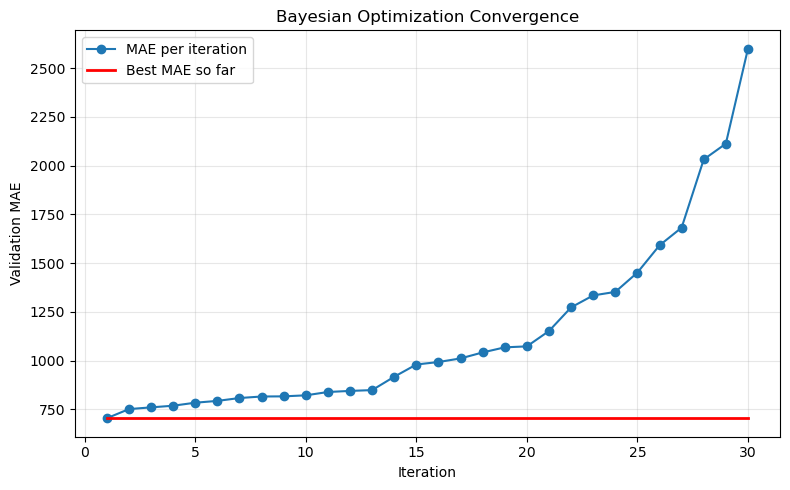

C:\Users\mrast\AppData\Local\Temp\ipykernel_30532\1661535910.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")


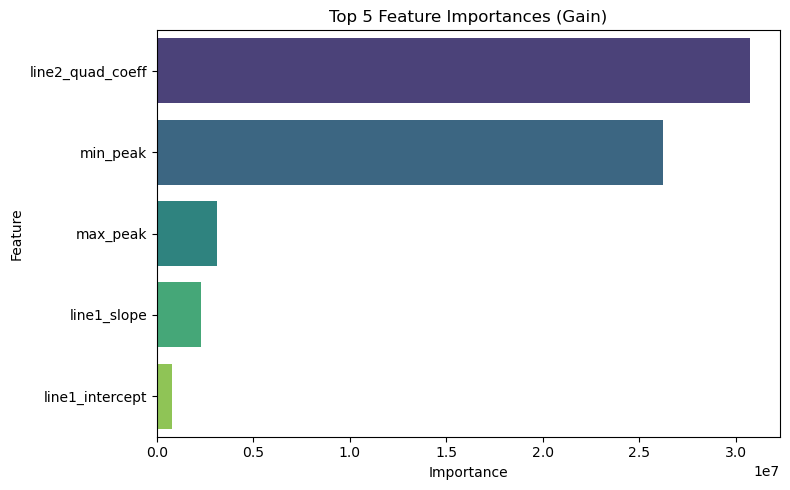


Visualization complete — convergence curve and feature importances plotted.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Load BayesSearchCV results
try:
    df_opt = pd.read_csv("bayes_cv_results.csv")
    print(f"Loaded {len(df_opt)} BayesSearchCV iterations.")
except FileNotFoundError:
    df_opt = None
    print("⚠️ No detailed CV results found — plotting from JSON summary instead.")

# Load the tuned model info
with open("tuned_model.json", "r") as f:
    d = json.load(f)

best_params = d["bscv_result"]["best_parameters"]
best_score = d["bscv_result"]["best_score"]
subset_fraction = d.get("subset_fraction", 1.0)

print(f"\n✅ Best Bayesian optimization results:")
print(f"  - Best score (MAE): {abs(best_score):.4f}")
print(f"  - Best parameters: {best_params}")
print(f"  - Training subset fraction: {subset_fraction*100:.0f}%")

# 1️⃣ Plot Bayesian optimization convergence
if df_opt is not None:
    # Extract iteration order and test score
    df_opt_sorted = df_opt.sort_values("mean_test_score", ascending=False).reset_index(drop=True)
    df_opt_sorted["Iteration"] = np.arange(1, len(df_opt_sorted) + 1)
    best_so_far = df_opt_sorted["mean_test_score"].cummax()

    plt.figure(figsize=(8, 5))
    plt.plot(df_opt_sorted["Iteration"], -df_opt_sorted["mean_test_score"], marker="o", label="MAE per iteration")
    plt.plot(df_opt_sorted["Iteration"], -best_so_far, color="red", linewidth=2, label="Best MAE so far")
    plt.xlabel("Iteration")
    plt.ylabel("Validation MAE")
    plt.title("Bayesian Optimization Convergence")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 2️⃣ Feature importance from final XGBoost model
try:
    model = xgb.XGBRegressor(n_estimators=100, **best_params)
    model.load_model("visco_pred_model.json")  # Fixed filename
    importance = model.get_booster().get_score(importance_type="gain")
    importance_df = pd.DataFrame(list(importance.items()), columns=["Feature", "Importance"])
    importance_df = importance_df.sort_values("Importance", ascending=False).head()

    plt.figure(figsize=(8, 5))
    sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
    plt.title("Top 5 Feature Importances (Gain)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"⚠️ Could not plot feature importances: {e}")

# 3️⃣ Optional note
print("\nVisualization complete — convergence curve and feature importances plotted.")

## 7 - Run tuned model on test data and export predictions

In [20]:
# Load tuned model info and selected features
with open("tuned_model.json", "r") as f:
    d = json.load(f)

selected_features = d["features"]
best_params = d["bscv_result"]["best_parameters"]

# Load trained model
model = xgb.XGBRegressor(n_estimators=100, **best_params)
model.load_model("visco_pred_model.json")

# Load test data
df_test = load_test()

# Keep the first column (likely material name or ID)
first_col = df_test.columns[0]
X_test = df_test[selected_features]

# Predict
y_pred = model.predict(X_test)

# Prepare results DataFrame
df_results = pd.DataFrame({
    first_col: df_test[first_col],
    "viscosity_cp": y_pred
})

# Save to CSV
output_path = "Data/predicted_viscosity.csv"
df_results.to_csv(output_path, index=False)

print(f"✅ Predictions saved to '{output_path}'")
print(f"Preview of predictions:\n")
print(df_results.head())

✅ Predictions saved to 'Data/predicted_viscosity.csv'
Preview of predictions:

  sample_name  viscosity_cp
0       water     16.896757
1       water     16.896757
2       water     35.120499
3       water     15.362513
4       water     16.896757


In [25]:
file_path_results = 'Data/predicted_viscosity.csv'
# Load the CSV into a pandas DataFrame
df_result = pd.read_csv(file_path_results)

In [30]:
import re

# Function to extract real viscosity from sample name
def extract_real_viscosity(sample_name):
    if sample_name.lower() == 'water':
        return 1.0
    elif sample_name.lower().startswith('si'):
        # Extract numeric part after 'si'
        match = re.search(r'si(\d+)', sample_name.lower())
        if match:
            return float(match.group(1))
    return None

# Add real viscosity column to df_results
df_results['real_viscosity_cp'] = df_results['sample_name'].apply(extract_real_viscosity)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

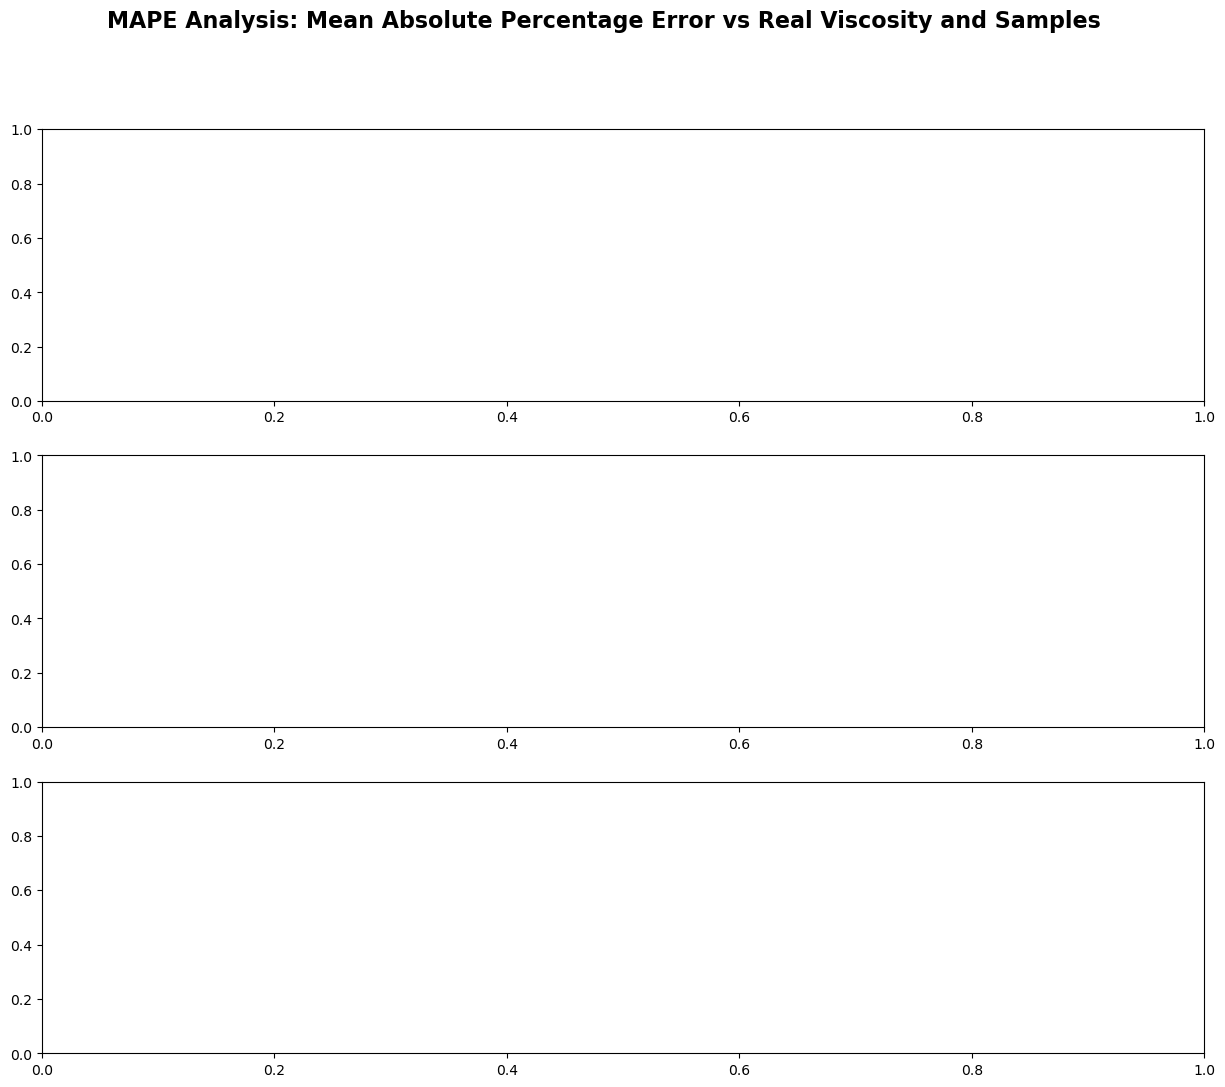

In [48]:
# Calculate and plot MAPE (Mean Absolute Percentage Error) vs real viscosity and samples
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to calculate MAPE safely (avoiding division by zero)
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error, handling zero values"""
    # Avoid division by zero by adding small epsilon to zero values
    epsilon = 1e-8
    y_true_safe = np.where(y_true == 0, epsilon, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    return mape

# Calculate MAPE for each data point
df_results['mape'] = np.abs((df_results['real_viscosity_cp'] - df_results['viscosity_cp']) / 
                           np.where(df_results['real_viscosity_cp'] == 0, 1e-8, df_results['real_viscosity_cp'])) * 100

# Create comprehensive MAPE visualization
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('MAPE Analysis: Mean Absolute Percentage Error vs Real Viscosity and Samples', 
             fontsize=16, fontweight='bold')

# 1. MAPE vs Real Viscosity scatter plot
ax1 = axes[0, 0]
for sample in df_results['sample_name'].unique():
    sample_data = df_results[df_results['sample_name'] == sample]
    ax1.scatter(sample_data['real_viscosity_cp'], sample_data['viscosity_cp'], 
               label=sample, alpha=0.7, s=60)

# Perfect prediction line (y=x)
min_val = min(df_results['real_viscosity_cp'].min(), df_results['viscosity_cp'].min())
max_val = max(df_results['real_viscosity_cp'].max(), df_results['viscosity_cp'].max())
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction', alpha=0.8)

ax1.set_xlabel('Real Viscosity (cP)')
ax1.set_ylabel('Predicted Viscosity (cP)')
ax1.set_title('Predicted vs Real Viscosity')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box plot of MAPE by sample type
ax2 = axes[1, 0]
mape_by_sample = [df_results[df_results['sample_name'] == sample]['mape'].values 
                 for sample in df_results['sample_name'].unique()]
box_plot = ax2.boxplot(mape_by_sample, tick_labels=df_results['sample_name'].unique(), 
                       patch_artist=True)

# Color the boxes
colors = sns.color_palette("husl", len(box_plot['boxes']))
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Sample Type')
ax2.set_ylabel('MAPE (%)')
ax2.set_title('Distribution of MAPE by Sample Type')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Bar plot: Average MAPE by sample
ax3 = axes[2, 0]
residuals_by_sample = [df_results[df_results['sample_name'] == sample]['residuals'].values 
                      for sample in df_results['sample_name'].unique()]
box_plot = ax3.boxplot(residuals_by_sample, labels=df_results['sample_name'].unique(), 
                       patch_artist=True)

# Color the boxes
colors = sns.color_palette("husl", len(box_plot['boxes']))
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_xlabel('Sample Type')
ax3.set_ylabel('Residuals (Predicted - Real)')
ax3.set_title('Distribution of Residuals by Sample Type')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Calculate and display overall MAPE statistics
overall_mape = calculate_mape(df_results['real_viscosity_cp'], df_results['viscosity_cp'])

print(f"\n📊 MAPE BY SAMPLE TYPE:")
for sample, avg_mape in zip(sample_names, avg_mape_by_sample):
    sample_data = df_results[df_results['sample_name'] == sample]
    median_mape = np.median(sample_data['mape'])
    std_mape = np.std(sample_data['mape'])
    print(f"   {sample}: Avg = {avg_mape:.2f}%, Median = {median_mape:.2f}%, Std = {std_mape:.2f}%")